- In this notebook, we will perform modeling and evaluation using Repeated Nested Cross-Validation (RNCV) on our dataset 
- We will compare the performance of different classifiers using both default and tuned hyperparameters 
- The results will be summarized statistically, and we will save the raw results for future reference

- The dataset has manually renamed to heart.csv
- We check the project structure and the libraries, to run properly the notebook

In [1]:
import os

# Define the project structure (relative to the main project directory)
# Since the notebook is in /notebooks, we go up one level with '..'
base_dir = ".."
required_folders = ["data", "figures", "models", "notebooks", "results", "src"]

print("--- Checking Project Structure ---")

for folder in required_folders:
    folder_path = os.path.join(base_dir, folder)
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"[CREATED] Folder: {folder}")
    else:
        print(f"[EXISTS]  Folder: {folder}")

# Check for required source files in /src
required_files = {
    "src": ["functions.py", "pipeline.py"]
}

for folder, files in required_files.items():
    for file in files:
        file_path = os.path.join(base_dir, folder, file)
        if not os.path.exists(file_path):
            print(f"[WARNING] Missing source file: {file_path}. Please ensure your code is present.")
        else:
            print(f"[OK]      Source file found: {file}")

print("----------------------------------")

--- Checking Project Structure ---
[EXISTS]  Folder: data
[EXISTS]  Folder: figures
[EXISTS]  Folder: models
[EXISTS]  Folder: notebooks
[EXISTS]  Folder: results
[EXISTS]  Folder: src
[OK]      Source file found: functions.py
[OK]      Source file found: pipeline.py
----------------------------------


In [2]:
import subprocess
import sys

def install_missing_packages():
    # List of required libraries for the project
    required_packages = [
        "numpy", 
        "pandas", 
        "scikit-learn", 
        "matplotlib", 
        "seaborn", 
        "xgboost", 
        "lightgbm", 
        "catboost", 
        "shap", 
        "scipy"
    ]
    
    print("--- Checking Required Libraries ---")
    
    for package in required_packages:
        try:
            # Attempt to import the library (some have different import names)
            import_name = package
            if package == "scikit-learn": import_name = "sklearn"
            
            __import__(import_name)
            print(f"[OK]      {package} is already installed.")
        except ImportError:
            print(f"[INSTALL] {package} not found. Installing...")
            # Execute installation via pip
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            print(f"[DONE]    {package} installed successfully.")

    print("-----------------------------------\n")

# Execute the function
install_missing_packages()

--- Checking Required Libraries ---
[OK]      numpy is already installed.
[OK]      pandas is already installed.
[OK]      scikit-learn is already installed.
[OK]      matplotlib is already installed.
[OK]      seaborn is already installed.
[OK]      xgboost is already installed.
[OK]      lightgbm is already installed.
[OK]      catboost is already installed.
[OK]      shap is already installed.
[OK]      scipy is already installed.
-----------------------------------



/home/mdliassa/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--------------------------

## Task 3


Task 3.1 is the construction of the  Repeated Nested Cross-Validation Class and is located in the pipeline.py file under the src folder of this notebok

Task 3.2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier


In [4]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [5]:
import sys
import os

# Ensure that the root of the project is in the path
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

# Importing the necessary functions and classes from the src directory
from src.functions import load_heart_disease_data
from src.pipeline import RepeatedNestedCV

In [6]:
# Load raw dataset 
data_path = "../data/heart.csv"

# Load the data
df = load_heart_disease_data(data_path)

# # Define categorical columns based on EDA insights
categorical_cols = ['sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal'] 

# Transform to 'category' dtype (helps the OneHotEncoder)
for col in categorical_cols:
    df[col] = df[col].astype('category')

print("Data are ready-Types converted for Pipeline.") 

Data are ready-Types converted for Pipeline.


## Task 3.2 

Inputs and Model Definition 



- We will use the same set of estimators for both phases (baseline and tuned) 
- This allows us to directly compare the impact of hyperparameter tuning on the same models

Defining Models and Hyperparameter Space

- **Estimators**: We define 7 different classification algorithms, ranging from simple linear models (LR, LDA) to advanced ensemble methods (Random Forest, XGBoost, CatBoost)
       
-  **Parameter Spaces**: We define the dictionaries containing the hyperparameters to be searched
   * The `classifier__` prefix is used for compatibility with **Scikit-learn Pipelines** - since the estimators are inside a Pipeline
   * For the **GNB** and **LDA** algorithms, we use empty dictionaries since they are based on statistical calculations without the need for extensive tuning

In [7]:
# Definition of the 7 required algorithms
estimators = {
    # Logistic Regression with ElasticNet: combines L1 & L2 regularization 
    'LR_ElasticNet': LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000, random_state=42), # solver='saga' because it's the only one that supports elasticnet
    # Gaussian Naive Bayes
    'GNB': GaussianNB(),
    # # Linear Discriminant Analysis : linear classifier that finds a linear combination of features to separate classes, effective for small datasets
    'LDA': LinearDiscriminantAnalysis(),
    # Random Forest : ensemble of decision trees that reduces overfitting and improves generalization, good for tabular data
    'RF': RandomForestClassifier(random_state=42),
    # LightGBM : Gradient Boosting framework that is efficient and fast, especially for large datasets
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1),
    # XGBoost : Another powerful Gradient Boosting implementation that is widely used for its performance and flexibility
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    # CatBoost : Gradient Boosting algorithm that handles categorical features natively and is robust to overfitting, good for tabular data
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

# Definition of Hyperparameter Spaces (Task 3.2)
param_spaces = {
    'LR_ElasticNet': {'classifier__C': [0.1, 1.0, 10.0], 'classifier__l1_ratio': [0.2, 0.5, 0.8]}, # C: inverse of regularization strength, l1_ratio: balance between L1 and L2 regularization
    'GNB': {}, # GaussianNB has no hyperparameters to tune in this context
    'LDA': {}, # Linear Discriminant Analysis has no hyperparameters to tune in this context
    'RF': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [None, 5, 10]}, # n_estimators: number of trees, max_depth: maximum depth of the tree
    'LightGBM': {'classifier__learning_rate': [0.01, 0.1], 'classifier__n_estimators': [50, 100]}, # learning_rate: step size at each iteration, n_estimators: number of boosting rounds
    'XGBoost': {'classifier__learning_rate': [0.01, 0.1], 'classifier__n_estimators': [50, 100]}, # learning_rate: step size at each iteration, n_estimators: number of boosting rounds
    'CatBoost': {'classifier__depth': [4, 6], 'classifier__learning_rate': [0.01, 0.1]} # depth: depth of the tree, learning_rate: step size at each iteration
}

# Definition of the list of metrics to be shown (Task 3.1)
metrics_to_show = ['MCC', 'AUC', 'BA', 'F1', 'Recall', 'Specificity', 'Precision', 'PRAUC']

In [8]:
# Defining the root results path
root_results_path = os.path.join('..', 'results')

# Creating the results directory if it doesn't exist
if not os.path.exists(root_results_path):
    os.makedirs(root_results_path)
    print(f"Directory created at: {os.path.abspath(root_results_path)}")

Baseline Comparison (Default Hyperparameters)

- During Phase A we run the Repeated Nested CV without tuning (tune_hyperparameters=False)
- This gives us an initial estimate of their performance

In [9]:
print("--- Starting Phase A: Baseline Comparison (Default Parameters) ---")

rncv = RepeatedNestedCV(df, estimators, param_spaces, R=10, N=5)
# Run without tuning (tune_hyperparameters=False)
baseline_raw = rncv.run(tune_hyperparameters=False)
# Create statistical summary (for Phase A = default parameters)
baseline_summary = rncv.get_statistical_summary(baseline_raw)

# Sort by MCC and display results
# mcc in the main metric for comparison because it is a balanced metric that considers all confusion matrix components, making it ideal for imbalanced datasets like ours.
print("Baseline Results (Median & 95% CI):")
#display(baseline_summary.sort_values('MCC_median', ascending=False))
display(baseline_summary)

--- Starting Phase A: Baseline Comparison (Default Parameters) ---
Baseline Results (Median & 95% CI):


,Algorithm,MCC_median,MCC_95CI,AUC_median,AUC_95CI,BA_median,BA_95CI,F1_median,F1_95CI,Recall_median,Recall_95CI,Specificity_median,Specificity_95CI,Precision_median,Precision_95CI,PRAUC_median,PRAUC_95CI
0,LR_ElasticNet,0.678299,"(0.624, 0.712)",0.904817,"(0.897, 0.911)",0.832358,"(0.813, 0.848)",0.813853,"(0.791, 0.833)",0.782609,"(0.773, 0.818)",0.884615,"(0.846, 0.923)",0.861905,"(0.818, 0.897)",0.901585,"(0.883, 0.922)"
1,GNB,0.559501,"(0.512, 0.585)",0.886288,"(0.869, 0.903)",0.767483,"(0.747, 0.778)",0.770580,"(0.755, 0.782)",0.863636,"(0.818, 0.909)",0.653846,"(0.593, 0.731)",0.677995,"(0.655, 0.724)",0.863332,"(0.835, 0.902)"
2,LDA,0.653512,"(0.623, 0.706)",0.895979,"(0.89, 0.906)",0.820804,"(0.804, 0.844)",0.791182,"(0.782, 0.823)",0.772727,"(0.727, 0.818)",0.884615,"(0.852, 0.923)",0.853571,"(0.81, 0.882)",0.899822,"(0.881, 0.914)"
3,RF,0.588156,"(0.549, 0.664)",0.878497,"(0.866, 0.91)",0.791102,"(0.773, 0.829)",0.765568,"(0.756, 0.81)",0.739130,"(0.727, 0.778)",0.846154,"(0.811, 0.868)",0.795833,"(0.778, 0.822)",0.881693,"(0.865, 0.915)"
4,LightGBM,0.582894,"(0.527, 0.6)",0.861953,"(0.848, 0.881)",0.788462,"(0.763, 0.799)",0.772727,"(0.75, 0.783)",0.772727,"(0.739, 0.8)",0.807692,"(0.769, 0.846)",0.772727,"(0.75, 0.791)",0.860814,"(0.843, 0.887)"
5,XGBoost,0.549405,"(0.537, 0.594)",0.868752,"(0.844, 0.883)",0.774476,"(0.76, 0.795)",0.760757,"(0.737, 0.783)",0.772727,"(0.727, 0.818)",0.807692,"(0.793, 0.815)",0.770979,"(0.743, 0.786)",0.864763,"(0.853, 0.88)"
6,CatBoost,0.615624,"(0.585, 0.631)",0.883385,"(0.865, 0.9)",0.803322,"(0.793, 0.812)",0.780488,"(0.773, 0.791)",0.772727,"(0.733, 0.818)",0.846154,"(0.811, 0.885)",0.809524,"(0.773, 0.838)",0.882017,"(0.869, 0.908)"


In [10]:
from src.functions import format_results_table

In [11]:
df_default_formatted = format_results_table(baseline_summary, 'Default')

# Save in results folder and display
df_default_formatted.to_csv('../results/formatted_baseline_summary.csv', index=False)
display(df_default_formatted)

,Model,Stage,MCC_median,95% CI (MCC),AUC_median,BA_median,F1_median,Recall_median,Precision_median
0,LR_ElasticNet,Default,0.678,"[0.624, 0.712]",0.905,0.832,0.814,0.783,0.862
1,GNB,Default,0.560,"[0.512, 0.585]",0.886,0.767,0.771,0.864,0.678
2,LDA,Default,0.654,"[0.623, 0.706]",0.896,0.821,0.791,0.773,0.854
3,RF,Default,0.588,"[0.549, 0.664]",0.878,0.791,0.766,0.739,0.796
4,LightGBM,Default,0.583,"[0.527, 0.600]",0.862,0.788,0.773,0.773,0.773
5,XGBoost,Default,0.549,"[0.537, 0.594]",0.869,0.774,0.761,0.773,0.771
6,CatBoost,Default,0.616,"[0.585, 0.631]",0.883,0.803,0.780,0.773,0.810


In [12]:
# Save baseline raw results to CSV under results directory
baseline_raw.to_csv('../results/raw_baseline_results.csv', index=False)

Full rnCV (Tuned Hyperparameters)

- During Phase B we run the Repeated Nested CV with tuning (tune_hyperparameters=False)
- This gives us the results for the tuned models and we can see how results change compared to the baseline

In [13]:
print("--- Starting Phase B: Full Repeated Nested CV (Hyperparameter Tuning) ---")

rncv_tuned = RepeatedNestedCV(df, estimators, param_spaces, R=10)
# Run with tuning (tune_hyperparameters=True)
# Experiment with inner_score='roc_auc' or 'f1'
tuned_raw = rncv.run(tune_hyperparameters=True, inner_score='roc_auc')
# Generate statistical summary (for Phase B = tuned parameters)
tuned_summary = rncv.get_statistical_summary(tuned_raw)

# Sort by MCC and display results
tuned_stats = tuned_summary.sort_values(by='MCC_median', ascending=False)
print("Tuned Results (Median & 95% CI):")
display(tuned_summary)


--- Starting Phase B: Full Repeated Nested CV (Hyperparameter Tuning) ---
Tuned Results (Median & 95% CI):


,Algorithm,MCC_median,MCC_95CI,AUC_median,AUC_95CI,BA_median,BA_95CI,F1_median,F1_95CI,Recall_median,Recall_95CI,Specificity_median,Specificity_95CI,Precision_median,Precision_95CI,PRAUC_median,PRAUC_95CI
0,LR_ElasticNet,0.669794,"(0.624, 0.684)",0.902227,"(0.886, 0.918)",0.829740,"(0.813, 0.839)",0.809524,"(0.791, 0.829)",0.772727,"(0.773, 0.818)",0.884615,"(0.846, 0.923)",0.850000,"(0.81, 0.889)",0.900771,"(0.878, 0.917)"
1,GNB,0.559501,"(0.512, 0.585)",0.886288,"(0.869, 0.903)",0.767483,"(0.747, 0.778)",0.770580,"(0.755, 0.782)",0.863636,"(0.818, 0.909)",0.653846,"(0.593, 0.731)",0.677995,"(0.655, 0.724)",0.863332,"(0.835, 0.902)"
2,LDA,0.653512,"(0.623, 0.706)",0.895979,"(0.89, 0.906)",0.820804,"(0.804, 0.844)",0.791182,"(0.782, 0.823)",0.772727,"(0.727, 0.818)",0.884615,"(0.852, 0.923)",0.853571,"(0.81, 0.882)",0.899822,"(0.881, 0.914)"
3,RF,0.587542,"(0.569, 0.642)",0.887998,"(0.869, 0.907)",0.793174,"(0.778, 0.809)",0.772727,"(0.756, 0.787)",0.755929,"(0.696, 0.773)",0.846154,"(0.815, 0.846)",0.800000,"(0.773, 0.818)",0.888139,"(0.872, 0.906)"
4,LightGBM,0.579979,"(0.542, 0.623)",0.861014,"(0.85, 0.899)",0.782537,"(0.767, 0.808)",0.763931,"(0.747, 0.791)",0.755929,"(0.727, 0.773)",0.830484,"(0.808, 0.852)",0.787138,"(0.762, 0.813)",0.863994,"(0.852, 0.896)"
5,XGBoost,0.544602,"(0.512, 0.585)",0.861079,"(0.841, 0.888)",0.769193,"(0.755, 0.788)",0.747093,"(0.735, 0.773)",0.772727,"(0.727, 0.8)",0.807692,"(0.778, 0.846)",0.766968,"(0.749, 0.796)",0.867486,"(0.854, 0.889)"
6,CatBoost,0.586456,"(0.541, 0.631)",0.872054,"(0.855, 0.904)",0.793706,"(0.771, 0.809)",0.769231,"(0.747, 0.791)",0.772727,"(0.696, 0.818)",0.830484,"(0.808, 0.846)",0.777778,"(0.75, 0.814)",0.867819,"(0.857, 0.902)"


In [14]:
df_tuned_formatted = format_results_table(tuned_summary, 'Tuned') 

# Save in results folder and display
#df_tuned_formatted.to_csv('../results/formatted_tuned_summary.csv', index=False)
display(df_tuned_formatted)

,Model,Stage,MCC_median,95% CI (MCC),AUC_median,BA_median,F1_median,Recall_median,Precision_median
0,LR_ElasticNet,Tuned,0.670,"[0.624, 0.684]",0.902,0.830,0.810,0.773,0.850
1,GNB,Tuned,0.560,"[0.512, 0.585]",0.886,0.767,0.771,0.864,0.678
2,LDA,Tuned,0.654,"[0.623, 0.706]",0.896,0.821,0.791,0.773,0.854
3,RF,Tuned,0.588,"[0.569, 0.642]",0.888,0.793,0.773,0.756,0.800
4,LightGBM,Tuned,0.580,"[0.542, 0.623]",0.861,0.783,0.764,0.756,0.787
5,XGBoost,Tuned,0.545,"[0.512, 0.585]",0.861,0.769,0.747,0.773,0.767
6,CatBoost,Tuned,0.586,"[0.541, 0.631]",0.872,0.794,0.769,0.773,0.778


In [15]:
# Save baseline raw results to CSV under results directory
tuned_raw.to_csv('../results/raw_tuned_results.csv', index=False)

We **concatenate** the 2 tables for visual comparison of result values

In [16]:
print("--- Creating Combined Comparison Table ---")

# Concatenation of formatted summaries 
df_initial_comparison = pd.concat([df_default_formatted, df_tuned_formatted], ignore_index=True)

# We sort so that the rows are side-by-side (e.g., LR Default, LR Tuned)
df_initial_comparison = df_initial_comparison.sort_values(by=['Model', 'Stage'], ascending=[True, False])

# We select the columns to display 
cols_to_show = ['Model', 'Stage', 'MCC_median', '95% CI (MCC)', 'AUC_median', 'Recall_median']
display(df_initial_comparison[cols_to_show])

# We save the final combined CSV
df_initial_comparison.to_csv('../results/initial_model_comparison_formatted.csv', index=False)

--- Creating Combined Comparison Table ---


,Model,Stage,MCC_median,95% CI (MCC),AUC_median,Recall_median
13,CatBoost,Tuned,0.586,"[0.541, 0.631]",0.872,0.773
6,CatBoost,Default,0.616,"[0.585, 0.631]",0.883,0.773
8,GNB,Tuned,0.560,"[0.512, 0.585]",0.886,0.864
1,GNB,Default,0.560,"[0.512, 0.585]",0.886,0.864
9,LDA,Tuned,0.654,"[0.623, 0.706]",0.896,0.773
2,LDA,Default,0.654,"[0.623, 0.706]",0.896,0.773
7,LR_ElasticNet,Tuned,0.670,"[0.624, 0.684]",0.902,0.773
0,LR_ElasticNet,Default,0.678,"[0.624, 0.712]",0.905,0.783
11,LightGBM,Tuned,0.580,"[0.542, 0.623]",0.861,0.756
4,LightGBM,Default,0.583,"[0.527, 0.600]",0.862,0.773


Best Parameters

In [17]:
print("Analysis of Frequency of 'Best_Params' from Tuned Results:")

for alg in tuned_raw['Algorithm'].unique():
    print(f"\n--- Algorithm: {alg} ---")
    alg_df = tuned_raw[tuned_raw['Algorithm'] == alg]
    
    # Convert dictionaries to frozensets for proper grouping
    # This handles cases where dictionary keys/values might have different order but represent the same params
    best_params_counts = alg_df['Best_Params'].apply(lambda x: frozenset(x.items()) if isinstance(x, dict) else x).value_counts()
    
    # Convert frozensets back to dicts for display if needed, or just display frozensets
    for params, count in best_params_counts.items():
        if isinstance(params, frozenset):
            display_params = dict(params)
        else:
            display_params = params # For 'default' or other non-dict values
        print(f"  {display_params}: {count} times")


Analysis of Frequency of 'Best_Params' from Tuned Results:

--- Algorithm: LR_ElasticNet ---
  {'classifier__C': 0.1, 'classifier__l1_ratio': 0.2}: 21 times
  {'classifier__C': 1.0, 'classifier__l1_ratio': 0.8}: 13 times
  {'classifier__C': 1.0, 'classifier__l1_ratio': 0.2}: 8 times
  {'classifier__C': 1.0, 'classifier__l1_ratio': 0.5}: 6 times
  {'classifier__C': 0.1, 'classifier__l1_ratio': 0.5}: 1 times
  {'classifier__C': 10.0, 'classifier__l1_ratio': 0.2}: 1 times

--- Algorithm: GNB ---
  default: 50 times

--- Algorithm: LDA ---
  default: 50 times

--- Algorithm: RF ---
  {'classifier__max_depth': 5, 'classifier__n_estimators': 100}: 20 times
  {'classifier__max_depth': 5, 'classifier__n_estimators': 200}: 18 times
  {'classifier__max_depth': 10, 'classifier__n_estimators': 100}: 6 times
  {'classifier__max_depth': None, 'classifier__n_estimators': 200}: 5 times
  {'classifier__max_depth': 10, 'classifier__n_estimators': 200}: 1 times

--- Algorithm: LightGBM ---
  {'classifier

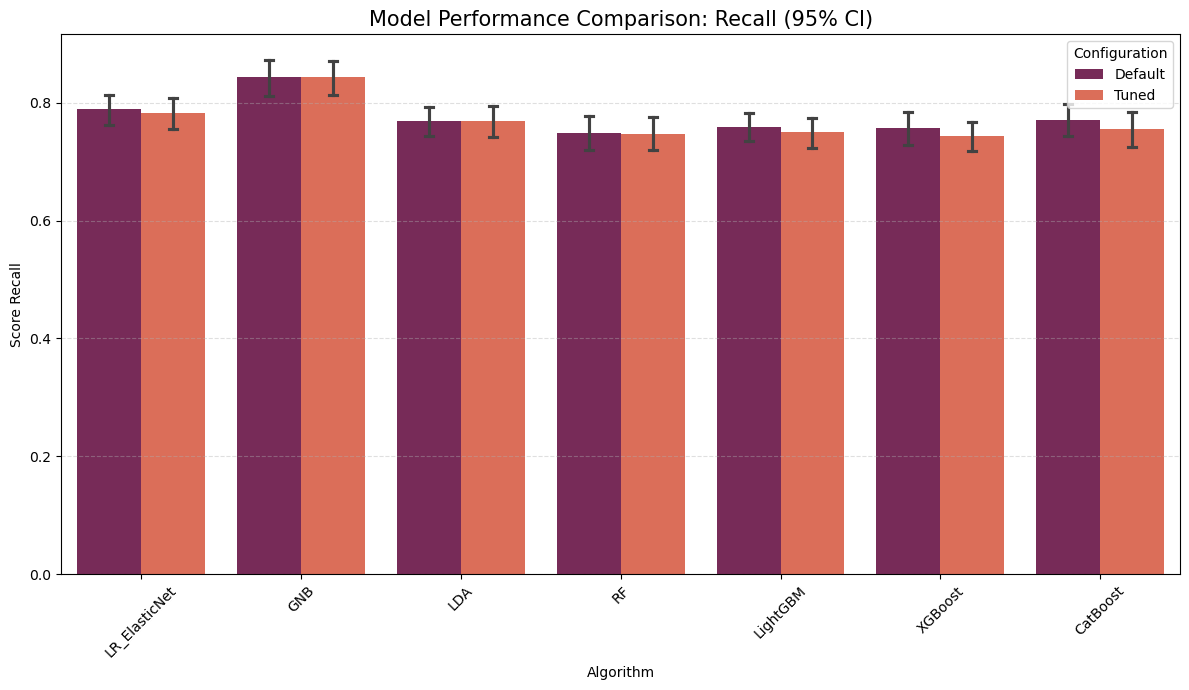

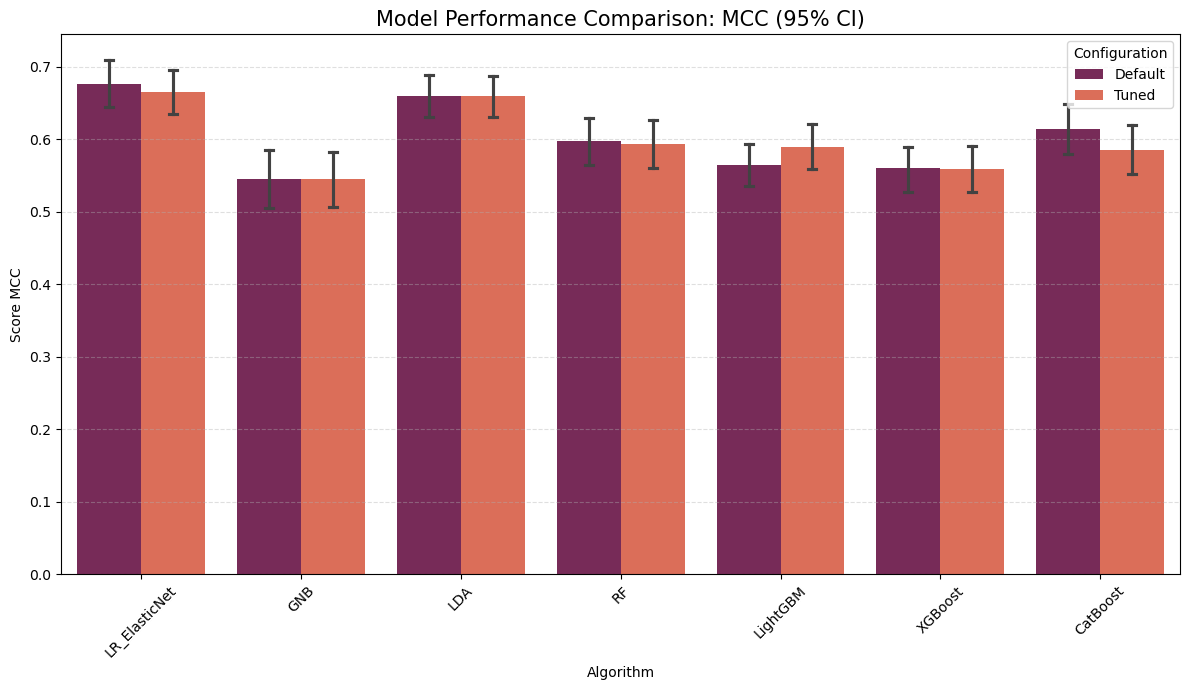

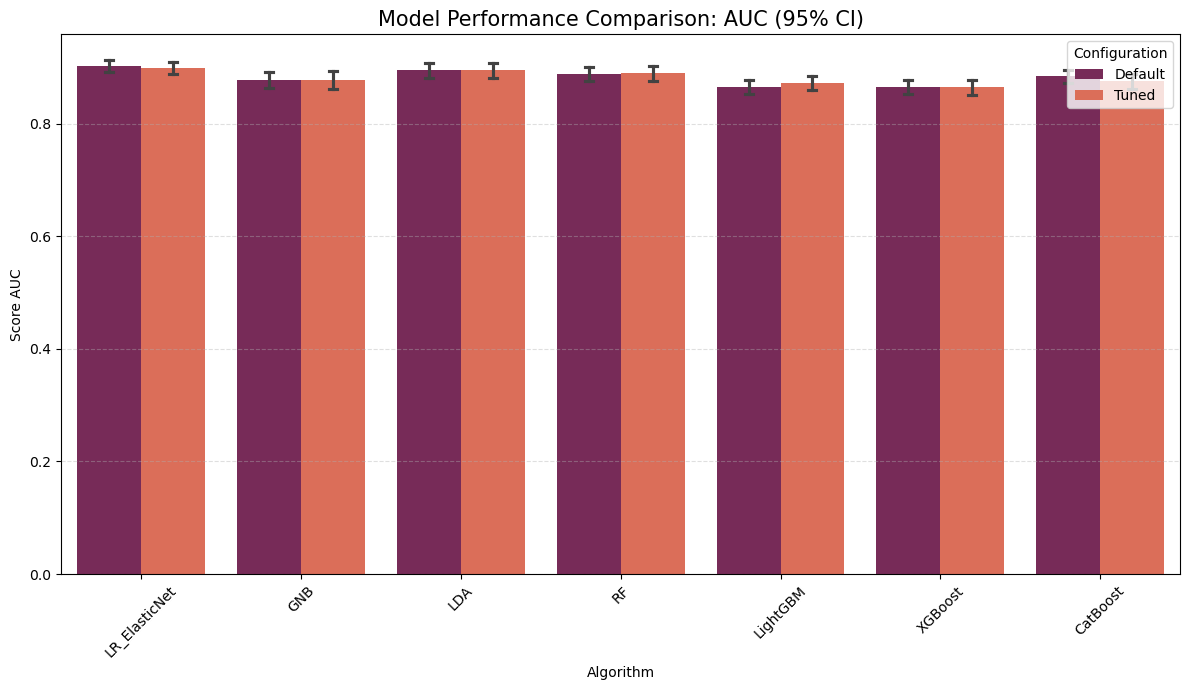

In [20]:
from src.functions import plot_simple_comparison

# 1.Add 'Stage' column to the RAW data
# We use .copy() to avoid SettingWithCopyWarning
baseline_raw_with_stage = baseline_raw.copy()
baseline_raw_with_stage['Stage'] = 'Default'

tuned_raw_with_stage = tuned_raw.copy()
tuned_raw_with_stage['Stage'] = 'Tuned'

# 2. Concatenate the RAW data
all_folds_data = pd.concat([baseline_raw_with_stage, tuned_raw_with_stage], ignore_index=True)

# 3. List of metrics (ensure names match columns in the dataframe)
metrics_to_visualize = ['Recall', 'MCC', 'AUC']

# 4. Execution of Plotting
for metric in metrics_to_visualize:
    plot_simple_comparison(all_folds_data, metric=metric)

## Task 4

In [ ]:
# Task 4: Feature Importance & Stability Analysis
winner_name = 'LR_ElasticNet' # Ή 'LDA' ανάλογα με τα αποτελέσματα
feature_importances = []

# Παίρνουμε τα ονόματα των features μετά το OneHot Encoding
# Χρειαζόμαστε ένα "fit" για να πάρουμε τα ονόματα των στηλών
temp_pipe = rncv._create_pipeline(estimators[winner_name])
temp_pipe.fit(rncv.X, rncv.y)
ohe_names = temp_pipe.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(rncv.cat_features)
all_feature_names = rncv.num_features + list(ohe_names)

print(f"Analyzing Feature Stability for: {winner_name}")

# Επανεκτέλεση (ή εξαγωγή από το tuned_raw αν αποθηκεύαμε τα μοντέλα)
# Για ευκολία, θα τρέξουμε ένα γρήγορο loop στα Outer Folds
for r in range(rncv.R):
    outer_cv = StratifiedKFold(n_splits=rncv.N, shuffle=True, random_state=rncv.seed + r)
    for train_idx, _ in outer_cv.split(rncv.X, rncv.y):
        X_tr, y_tr = rncv.X.iloc[train_idx], rncv.y.iloc[train_idx]
        
        # Fit winner with best params (προσεγγιστικά)
        model = rncv._create_pipeline(estimators[winner_name])
        model.fit(X_tr, y_tr)
        
        # Εξαγωγή συντελεστών (για γραμμικά μοντέλα)
        if winner_name in ['LR_ElasticNet', 'LDA']:
            coefs = model.named_steps['classifier'].coef_.flatten()
            feature_importances.append(np.abs(coefs))

# Υπολογισμός μέσης σημασίας και σταθερότητας
importance_df = pd.DataFrame(feature_importances, columns=all_feature_names)
stability_summary = pd.DataFrame({
    'Feature': all_feature_names,
    'Mean_Importance': importance_df.mean(),
    'Std_Importance': importance_df.std()
}).sort_values(by='Mean_Importance', ascending=False)

display(stability_summary)